# 01 — Is churn predictable at Vertex Systems?

Before building anything, two questions have to be answered with data rather than
with optimism:

1. **Is there enough churn to learn from?** A model needs positive examples, and a
   2% base rate over a short history may simply not contain enough.
2. **Does anything visible change before an account leaves?** If disengagement only
   becomes apparent on the day of the cancellation, no amount of modelling helps —
   the answer is a better cancellation flow, not a classifier.

Everything here reads the same feature store the training pipeline uses. This
notebook computes nothing of its own, on purpose: a notebook that reimplements a
feature is a notebook that will disagree with production.

> Synthetic data. Vertex Systems is an invented company.

In [1]:
import warnings, os
warnings.filterwarnings("ignore")
os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


In [2]:
from polaris.config import get_settings
from polaris.db.engine import get_engine

settings = get_settings()
engine = get_engine(settings)

accounts = pd.read_sql(f"SELECT * FROM {settings.source_schema}.account", engine)
print(f"{len(accounts):,} accounts, {accounts['churn_date'].notna().sum():,} of which churned")
accounts.groupby("segment").agg(
    accounts=("account_id", "count"),
    churned=("churn_date", lambda s: s.notna().sum()),
    mrr=("mrr_eur", "median"),
).assign(churn_rate=lambda d: (100 * d.churned / d.accounts).round(1))

3,000 accounts, 739 of which churned


,accounts,churned,mrr,churn_rate
segment,,,,
enterprise,296,15,8843.52,5.1
mid_market,845,139,1441.55,16.4
smb,1859,585,225.44,31.5


Churn is concentrated in SMB, which is what a B2B SaaS business normally sees and
what makes the per-segment promotion gate worth having: a model that improves the
average by getting better at SMB while getting worse at enterprise has improved
the number and damaged the business.

In [3]:
features = pd.read_sql(
    f"""SELECT * FROM {settings.feature_schema}.churn_features
        WHERE churned_in_horizon IS NOT NULL""",
    engine,
)
print(f"{len(features):,} labelled rows over {features.reference_date.nunique()} reference dates")
print(f"base rate: {100 * features.churned_in_horizon.mean():.2f}%")
features.groupby("reference_date").churned_in_horizon.agg(["count", "mean"]).tail(6)

95,774 labelled rows over 42 reference dates
base rate: 2.77%


,count,mean
reference_date,,
2025-10-17,2323,0.034869
2025-10-31,2329,0.035638
2025-11-14,2333,0.032576
2025-11-28,2328,0.030498
2025-12-12,2316,0.022884
2025-12-26,2299,0.015659


### Does usage fall before the cancellation?

This is the question the whole project depends on. The comparison below is between
accounts that churned within the next sixty days and accounts that did not, on the
same reference dates — so it is not confounded by seasonality.

In [4]:
usage_cols = ["seat_utilisation_28d", "usage_trend_28d_vs_90d", "zero_usage_days_28d",
              "days_since_last_use", "features_used_28d", "error_rate_28d"]
comparison = features.groupby("churned_in_horizon")[usage_cols].median().T
comparison.columns = ["stayed", "churned"]
comparison["ratio"] = (comparison["churned"] / comparison["stayed"]).round(2)
comparison.round(3)

,stayed,churned,ratio
seat_utilisation_28d,0.497,0.242,0.49
usage_trend_28d_vs_90d,1.000,0.864,0.86
zero_usage_days_28d,0.000,3.000,inf
days_since_last_use,1.000,1.000,1.00
features_used_28d,9.571,6.250,0.65
error_rate_28d,0.081,1.000,12.32


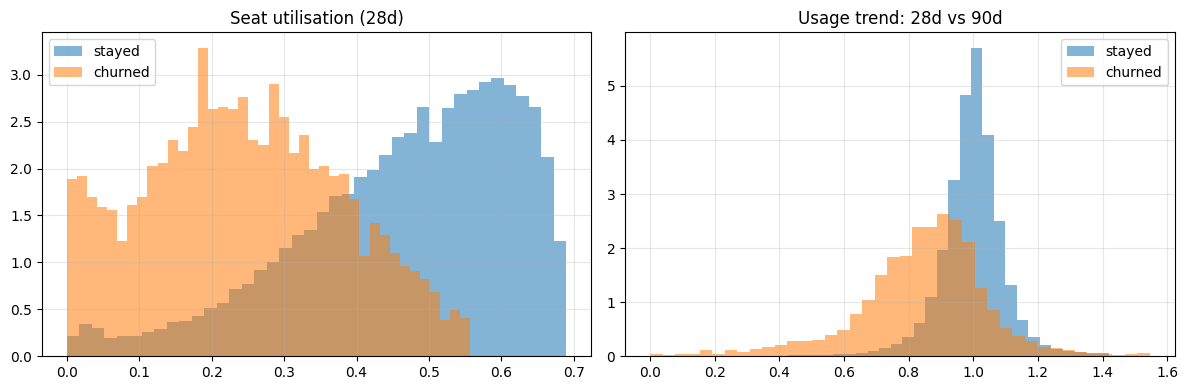

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(
    axes,
    ["seat_utilisation_28d", "usage_trend_28d_vs_90d"],
    ["Seat utilisation (28d)", "Usage trend: 28d vs 90d"],
):
    for label, name in [(False, "stayed"), (True, "churned")]:
        subset = features.loc[features.churned_in_horizon == label, col].dropna()
        subset = subset[subset < subset.quantile(0.99)]
        ax.hist(subset, bins=40, alpha=0.55, density=True, label=name)
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

The two distributions overlap heavily — which is the honest answer. Accounts on
their way out use the product less, but plenty of low-usage accounts renew happily
and plenty of active ones leave anyway. A model can exploit the difference; nobody
should expect it to be clean.

### What the base rate means for evaluation

At 2.7% positives, accuracy is a useless metric: predicting "nobody churns" scores
97.3%. The headline metric for this project is PR-AUC, and the operational one is
how many of the top hundred accounts really were leaving.

In [6]:
by_segment = features.groupby("segment").churned_in_horizon.agg(["count", "sum", "mean"])
by_segment.columns = ["rows", "churns", "base_rate"]
by_segment["accuracy_of_predicting_no"] = (1 - by_segment.base_rate).round(4)
by_segment.round(4)

,rows,churns,base_rate,accuracy_of_predicting_no
segment,,,,
enterprise,10709,53,0.0049,0.9951
mid_market,29148,525,0.0180,0.9820
smb,55917,2071,0.0370,0.9630
